# Entrega 1 — Dashboard de Apoio à Decisão Estratégica e Operacional
### Demonstrativo Financeiro Simulado — FECAP

**Objetivo geral do projeto:** desenvolver um dashboard capaz de apoiar decisões estratégicas e operacionais.


**Escopo desta entrega (Entrega 1):**
1. Identificar fontes de dados
2. Coletar dados iniciais
3. Descrever os dados
4. Explorar os dados
5. Selecionar os dados
6. Limpar e uniformizar os dados
7. Derivar e integrar os dados
8. Formatar os dados


Para que o código funcione corretamente, é necessário importar os arquivos CSV para este ambiente antes de iniciar a execução.

1. Baixe os arquivos: Acesse a pasta do projeto no **GitHub ---> Projeto3 ---> Documentos ---> Entrega 1 ---> Projeto Interdisciplinar Ciência de Dados** e faça o download dos arquivos .csv principais.

2. Abra os Arquivos do Colab: No menu lateral esquerdo desta tela, clique no ícone de Pasta.

3. Faça o Upload: Clique no ícone de upload (a folha com uma seta para cima) ou simplesmente arraste os arquivos .csv do seu computador para dentro desse menu lateral.

4. Execute o código: Aguarde a barra de carregamento dos arquivos terminar. Depois disso, você pode ir em Ambiente de execução > Executar tudo

## 0. Preparação do ambiente

In [20]:
# Bibliotecas utilizadas em toda a análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Identificação das fontes de dados

**Fonte:** arquivo `Demonstrativo_Fecap_v3.csv`, exportado de um modelo de simulação financeira (Monte Carlo) de uma concessão de infraestrutura.

**Formato original:** CSV, separador `;`, decimal `,`, codificação `ISO-8859-1 (Latin-1)`, sem cabeçalho.

**Estrutura (4 colunas):**
| Coluna | Conteúdo |
|---|---|
| `Ano` | Ano projetado do modelo (Ano 1 a Ano 12) |
| `Cenario` | Identificador do cenário simulado (Total Cen_00001 a Total Cen_01200 → 1.200 cenários) |
| `Conta` | Linha contábil (Balanço Patrimonial `BAL`, Demonstrativo de Resultado `DRE` ou Fluxo de Caixa `FLU`) |
| `Valor` | Valor monetário (R$) da conta naquele Ano/Cenário, ou a taxa anual do cenário quando `Conta` é vazio |

Trata-se, portanto, de dados **internos/gerados por modelo**, não de uma fonte externa — o que dispensa preocupações de licenciamento, mas exige atenção à consistência interna do modelo (o que é verificado nas etapas seguintes).

## 2. Coleta dos dados iniciais

No Colab, faça upload do arquivo (célula abaixo) ou monte o Google Drive. Em seguida os dados são lidos respeitando o separador `;`, o decimal `,` e a codificação `Latin-1` identificados na inspeção do arquivo bruto.

In [21]:
# Upload do arquivo no Colab
from google.colab import files
uploaded = files.upload()

CAMINHO_CSV = 'Demonstrativo Fecap v3.csv'
df = pd.read_csv(
    CAMINHO_CSV,
    sep=';',
    decimal=',',
    thousands='.',
    encoding='latin1',
    header=None,
    names=['Ano', 'Cenario', 'Conta', 'Valor']
)

print(f'Linhas: {df.shape[0]:,}  |  Colunas: {df.shape[1]}')
df.head()

Saving Demonstrativo Fecap v3.csv to Demonstrativo Fecap v3 (3).csv
Linhas: 1,002,000  |  Colunas: 4


,Ano,Cenario,Conta,Valor
0,Ano 1,Total Cen_00001,NaN,2.513881e-02
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07


## 3. Descrição dos dados

Levantamento do volume, tipos, cardinalidade e valores ausentes — base para o relatório de descrição dos dados (documento Word/PDF).

In [22]:
print('--- Tipos de dado ---')
print(df.dtypes)

print('\n--- Valores ausentes por coluna ---')
print(df.isna().sum())

print('\n--- Cardinalidade ---')
print('Anos distintos      :', df['Ano'].nunique())
print('Cenários distintos  :', df['Cenario'].nunique())
print('Contas distintas    :', df['Conta'].nunique(dropna=False), '(inclui linhas em branco = parâmetro de taxa)')

--- Tipos de dado ---
Ano         object
Cenario     object
Conta       object
Valor      float64
dtype: object

--- Valores ausentes por coluna ---
Ano            0
Cenario        0
Conta      43200
Valor          0
dtype: int64

--- Cardinalidade ---
Anos distintos      : 12
Cenários distintos  : 1200
Contas distintas    : 70 (inclui linhas em branco = parâmetro de taxa)


In [23]:
# Combinações Ano x Cenário e nº de linhas por combinação
combinacoes = df.groupby(['Ano', 'Cenario']).size()
print('Total de combinações Ano x Cenário:', combinacoes.shape[0], '(esperado: 12 x 1.200 = 14.400)')
print('\nDistribuição do nº de linhas por combinação:')
print(combinacoes.value_counts())

Total de combinações Ano x Cenário: 14400 (esperado: 12 x 1.200 = 14.400)

Distribuição do nº de linhas por combinação:
72    10800
71     2400
45     1200
Name: count, dtype: int64


**Achado relevante:** o número de linhas por combinação Ano/Cenário não é constante (45, 71 ou 72). Investigando quais contas somem em cada caso:

In [24]:
ref = set(df[(df['Ano'] == 'Ano 5') & (df['Cenario'] == 'Total Cen_00001')]['Conta'].dropna())
ano1 = set(df[(df['Ano'] == 'Ano 1') & (df['Cenario'] == 'Total Cen_00001')]['Conta'].dropna())
ano12 = set(df[(df['Ano'] == 'Ano 12') & (df['Cenario'] == 'Total Cen_00001')]['Conta'].dropna())

print('Conta ausente no Ano 1 (vs. um ano intermediário):', ref - ano1)
print('\nContas ausentes no Ano 12:', len(ref - ano12), 'de', len(ref))

Conta ausente no Ano 1 (vs. um ano intermediário): {'BAL  - Dividendos Antecipados'}

Contas ausentes no Ano 12: 27 de 69


Isso mostra que o **Ano 12 é o ano de encerramento da concessão**: praticamente todas as contas de Balanço Patrimonial desaparecem (os ativos revertem ao poder concedente), restando apenas indicadores de resultado e caixa. O **Ano 1** apenas não possui a conta "Dividendos Antecipados" (não há saldo anterior a distribuir). Essa informação é importante para o dashboard, que precisa tratar o Ano 12 como um período estruturalmente diferente.

## 4. Exploração dos dados

Análise exploratória para entender o comportamento das principais contas ao longo dos anos e entre os 1.200 cenários simulados.

In [25]:
# Estatísticas descritivas das contas de resultado mais relevantes
principais = ['DRE - Receita', 'DRE - Custos', 'DRE - EBITDA', 'DRE - Resultado Líquido']
pivot_check = df[df['Conta'].isin(principais)].pivot_table(
    index=['Ano', 'Cenario'], columns='Conta', values='Valor'
)
pivot_check.describe().T

,count,mean,std,min,25%,50%,75%,max
Conta,,,,,,,,
DRE - Custos,14400.0,-1.205407e+09,1.159152e+08,-1.454499e+09,-1.315814e+09,-1.215729e+09,-1.104737e+09,-8.607598e+08
DRE - EBITDA,14400.0,6.504509e+09,1.814815e+09,4.320029e+09,5.162452e+09,5.937502e+09,7.191377e+09,1.376148e+10
DRE - Receita,14400.0,7.913424e+09,1.668430e+09,5.751580e+09,6.564653e+09,7.336984e+09,8.820528e+09,1.458960e+10
DRE - Resultado Líquido,14400.0,3.356646e+09,1.332705e+09,1.653486e+09,2.334704e+09,2.978877e+09,3.763920e+09,8.234441e+09


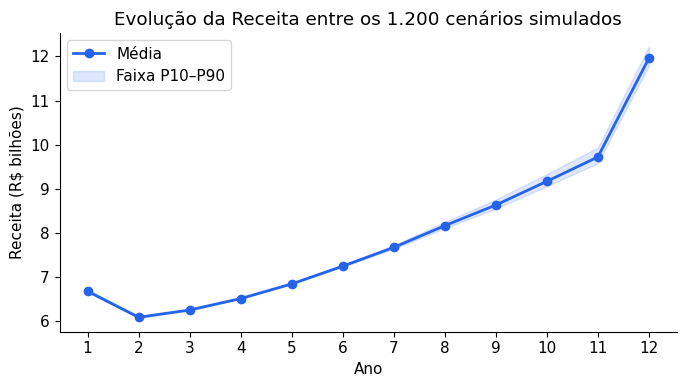

In [26]:
# Evolução da Receita média por ano, com faixa entre os percentis 10 e 90 dos cenários
receita = df[df['Conta'] == 'DRE - Receita'].copy()
receita['Ano_num'] = receita['Ano'].str.extract(r'(\d+)').astype(int)
g = receita.groupby('Ano_num')['Valor'].agg(['mean', lambda x: x.quantile(0.1), lambda x: x.quantile(0.9)])
g.columns = ['media', 'p10', 'p90']

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(g.index, g['media'] / 1e9, color='#2563eb', lw=2, marker='o', label='Média')
ax.fill_between(g.index, g['p10'] / 1e9, g['p90'] / 1e9, color='#2563eb', alpha=0.15, label='Faixa P10–P90')
ax.set_xlabel('Ano'); ax.set_ylabel('Receita (R$ bilhões)')
ax.set_title('Evolução da Receita entre os 1.200 cenários simulados')
ax.legend(); ax.set_xticks(range(1, 13))
plt.tight_layout(); plt.show()

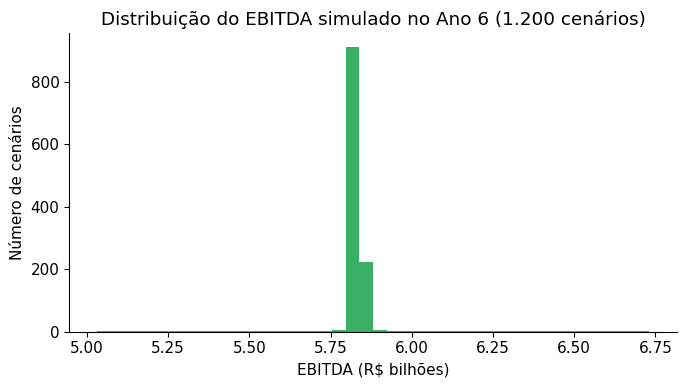

In [27]:
# Distribuição do EBITDA em um ano específico (Ano 6) entre os cenários
ebitda = df[df['Conta'] == 'DRE - EBITDA'].copy()
ebitda['Ano_num'] = ebitda['Ano'].str.extract(r'(\d+)').astype(int)
ano6 = ebitda[ebitda['Ano_num'] == 6]['Valor'] / 1e9

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ano6, bins=40, color='#16a34a', alpha=0.85)
ax.set_xlabel('EBITDA (R$ bilhões)'); ax.set_ylabel('Número de cenários')
ax.set_title('Distribuição do EBITDA simulado no Ano 6 (1.200 cenários)')
plt.tight_layout(); plt.show()

A exploração indica que a incerteza (largura da faixa P10–P90) é pequena nos primeiros anos e cresce com o tempo, e que a distribuição do EBITDA por cenário se aproxima de uma normal — comportamento típico de simulação de Monte Carlo com poucas variáveis aleatórias por ano.

## 5. Seleção dos dados

Nem todas as 69 contas originais agregam valor direto ao dashboard estratégico/operacional. Foram selecionadas as contas que compõem os três blocos de indicadores mais usados em painéis de gestão financeira:

- **Resultado (DRE):** Receita, Custos, EBITDA, Resultado Financeiro, Resultado Líquido
- **Posição patrimonial (BAL):** Total do Ativo, Total do Passivo, Ativo/Passivo Circulante, Empréstimos, Patrimônio Líquido
- **Caixa (FLU):** Geração de Caixa, Investimentos, Distribuição para Acionista, Saldo Final

As demais contas (detalhamentos contábeis muito granulares, como subcontas de créditos tributários ou outorga) permanecem disponíveis no dataset tratado, mas não entram como indicadores de primeira linha do dashboard — evitando poluição visual sem descartar a informação.

In [28]:
contas_dashboard = [
    'DRE - Receita', 'DRE - Custos', 'DRE - EBITDA', 'DRE - Resultado Financeiro',
    'DRE - Resultado Líquido', 'BAL - Total do Ativo', 'BAL - Total do Passivo',
    'BAL - Ativo Circulante', 'BAL - Passivo Circulante', 'BAL - Patrimônio Líquido',
    'FLU - Geração de Caixa', 'FLU - Investimentos', 'FLU - Distribuição para Acionista',
    'FLU - Saldo Final'
]
print(f'{len(contas_dashboard)} contas selecionadas como indicadores centrais do dashboard.')

14 contas selecionadas como indicadores centrais do dashboard.


## 6. Limpeza e uniformização dos dados

Tratamentos aplicados:
1. **Separação do parâmetro de taxa** — as linhas com `Conta` em branco não são "sujeira": 1 em cada 3 carrega a taxa anual daquele cenário (as outras 2 são zeros estruturais). Extraímos essa taxa para uma tabela auxiliar.
2. **Padronização de texto** — remoção de espaços duplicados nos nomes de conta (ex.: `"BAL  - Capital Social"` → `"BAL - Capital Social"`).
3. **Desambiguação de nomes truncados** — `"BAL - Emprést"` e `"BAL - Outros deb"` são contas de longo prazo distintas das de curto prazo (`"BAL - Empréstimos"`, `"BAL - Outros Débitos"`); foram renomeadas para não serem confundidas nem indevidamente agregadas.
4. **Tipagem numérica** — conversão de `Valor` (formato brasileiro, `.` milhar / `,` decimal) para `float`.
5. **Chaves ordenáveis** — extração da parte numérica de `Ano` e `Cenario` para permitir ordenação correta (evita que "Ano 10" seja ordenado antes de "Ano 2" como texto).

In [29]:
# 1. Separar o parâmetro de taxa (linhas com Conta em branco)
taxa = df[df['Conta'].isna()].copy()
taxa = taxa[taxa['Valor'] != 0][['Ano', 'Cenario', 'Valor']].rename(columns={'Valor': 'Taxa_Anual'})
print('Linhas de taxa extraídas:', len(taxa), '(esperado: 12 anos x 1.200 cenários = 14.400)')

# 2-3-4. Limpeza do dataset principal
main = df[df['Conta'].notna()].copy()
main['Conta'] = main['Conta'].str.strip().str.replace(r'\s+', ' ', regex=True)

rename_map = {
    'BAL - Emprést': 'BAL - Empréstimos LP',
    'BAL - Outros deb': 'BAL - Outros Débitos LP',
}
main['Conta'] = main['Conta'].replace(rename_map)

# 5. Chaves numéricas para ordenação
main['Ano_num'] = main['Ano'].str.extract(r'(\d+)').astype(int)
main['Cenario_num'] = main['Cenario'].str.extract(r'(\d+)').astype(int)

print('Contas distintas após limpeza:', main['Conta'].nunique())
main.head()

Linhas de taxa extraídas: 14400 (esperado: 12 anos x 1.200 cenários = 14.400)
Contas distintas após limpeza: 69


,Ano,Cenario,Conta,Valor,Ano_num,Cenario_num
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10,1,1
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09,1,1
3,Ano 1,Total Cen_00001,BAL - Disponível,1.205265e+09,1,1
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07,1,1
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,5.846615e+05,1,1


## 7. Derivação e integração dos dados

Nesta etapa:
- Os dados são **pivotados** de formato longo (uma linha por Ano/Cenário/Conta) para **largo** (uma linha por Ano/Cenário, uma coluna por conta) — formato exigido pela maioria das ferramentas de dashboard.
- A tabela de **taxa anual** é integrada de volta ao dataset largo.
- São **derivados indicadores financeiros** que não existem explicitamente no CSV original, mas que são essenciais para decisões estratégicas: margem EBITDA, margem líquida, ROE e liquidez corrente.

In [30]:
import numpy as np

# Pivot para formato largo (uma linha por Ano/Cenário)
wide = main.pivot_table(
    index=['Ano', 'Ano_num', 'Cenario', 'Cenario_num'],
    columns='Conta', values='Valor', aggfunc='first'
).reset_index()

# Integração do parâmetro de taxa
wide = wide.merge(taxa, on=['Ano', 'Cenario'], how='left')

# Indicadores derivados
wide['Margem_EBITDA'] = wide['DRE - EBITDA'] / wide['DRE - Receita']
wide['Margem_Liquida'] = wide['DRE - Resultado Líquido'] / wide['DRE - Receita']

# uso do np.where para evitar divisão por zero ou distorções se o PL for negativo.
pl_corrigido = -wide['BAL - Patrimônio Líquido']
wide['ROE'] = np.where(pl_corrigido > 0, wide['DRE - Resultado Líquido'] / pl_corrigido, np.nan)

# Liquidez Corrente
wide['Liquidez_Corrente'] = wide['BAL - Ativo Circulante'] / wide['BAL - Passivo Circulante'].abs()

print('Formato final (linhas, colunas):', wide.shape)
wide[['Ano', 'Cenario', 'DRE - Receita', 'DRE - EBITDA', 'Margem_EBITDA', 'Margem_Liquida', 'ROE']].head()

Formato final (linhas, colunas): (14400, 78)


,Ano,Cenario,DRE - Receita,DRE - EBITDA,Margem_EBITDA,Margem_Liquida,ROE
0,Ano 1,Total Cen_00001,6.722729e+09,5.188381e+09,0.771767,0.363430,1.212867
1,Ano 1,Total Cen_00002,6.703608e+09,5.172388e+09,0.771583,0.363470,1.213576
2,Ano 1,Total Cen_00003,6.676361e+09,5.149189e+09,0.771257,0.364688,1.213764
3,Ano 1,Total Cen_00004,6.672623e+09,5.146146e+09,0.771233,0.364982,1.213701
4,Ano 1,Total Cen_00005,6.660653e+09,5.136879e+09,0.771228,0.362729,1.215785


**Correlação entre os principais indicadores**, útil para identificar quais métricas realmente precisam de destaque separado no dashboard (indicadores muito correlacionados podem ser resumidos):

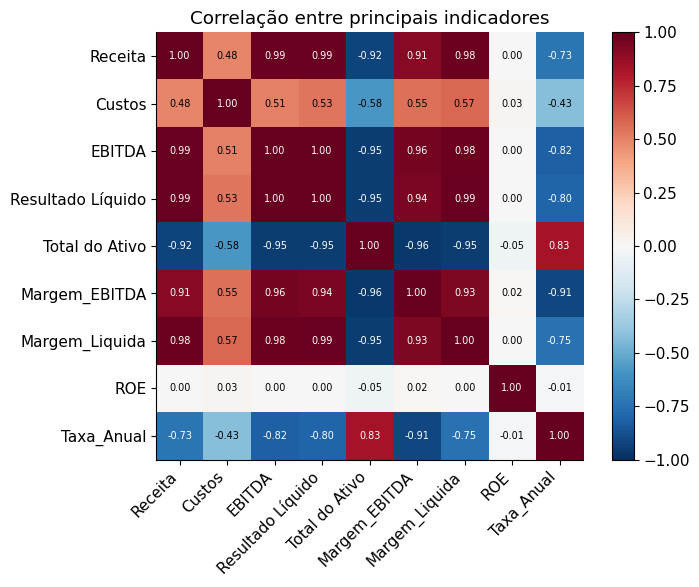

In [31]:
cols = ['DRE - Receita', 'DRE - Custos', 'DRE - EBITDA', 'DRE - Resultado Líquido',
        'BAL - Total do Ativo', 'Margem_EBITDA', 'Margem_Liquida', 'ROE', 'Taxa_Anual']
corr = wide[cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
labels = [c.replace('DRE - ', '').replace('BAL - ', '') for c in cols]
ax.set_xticks(range(len(cols))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(cols))); ax.set_yticklabels(labels)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlação entre principais indicadores')
plt.tight_layout(); plt.show()

## 8. Formatação final dos dados

Ordenação, tipagem e exportação dos dados tratados em dois formatos:

- **Formato largo** (`demonstrativo_fecap_tratado.csv`) — uma linha por Ano/Cenário, com todos os indicadores como colunas. Ideal para ferramentas de BI (Power BI, Streamlit, etc.).
- **Formato longo limpo** (`demonstrativo_fecap_long_limpo.csv`) — mantém a granularidade original (Ano/Cenário/Conta/Valor), útil para filtros dinâmicos por conta.

In [32]:
from google.colab import files

nome_do_arquivo = 'Contabilidade e Finanças.xlsx'

print('Disponibilizando o arquivo final e estruturado')
print(f' - {nome_do_arquivo}')

# Este comando força o Colab a baixar o seu arquivo pronto para o seu computador
files.download(nome_do_arquivo)

Disponibilizando o arquivo final e estruturado
 - Contabilidade e Finanças.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Resumo da Entrega 1

| Etapa | Resultado |
|---|---|
| Fontes de dados | 1 arquivo CSV, simulação de 1.200 cenários x 12 anos x 69 contas contábeis |
| Coleta | 1.002.000 linhas lidas com sucesso (encoding Latin-1, separador `;`) |
| Descrição | Sem valores nulos; Ano 12 identificado como ano de encerramento da concessão |
| Exploração | Receita e EBITDA crescentes ao longo dos anos; incerteza entre cenários aumenta com o tempo |
| Seleção | 14 contas centrais escolhidas para os indicadores de primeira linha do dashboard |
| Limpeza | Nomes padronizados, taxa anual isolada, tipos numéricos corrigidos |
| Derivação/Integração | 4 indicadores calculados (Margem EBITDA, Margem Líquida, ROE, Liquidez Corrente); dataset pivotado e integrado |
| Formatação | Dataset final exportado em formato largo (14.400 linhas x 78 colunas) e longo, prontos para o dashboard |
